Regression Logistique

In [2]:
import numpy as np                           
import pandas as pd                          
import matplotlib.pyplot as plt              

print("RÉGRESSION LOGISTIQUE (from scratch)")

df = pd.read_csv('auto_mpg.csv')
# creer la variable cible binaire : 1 si mpg > median (voiture économique), 0 sinon
df['economique'] = (df['mpg'] > df['mpg'].median()).astype(int)

features = ['weight', 'horsepower']          # variables explicatives (2D pour visualisation)
X = df[features].values                      # variable explicative sous forme de matrice
y = df['economique'].values                  # variable cible : 0=non économique, 1=économique





def normaliser(X):                                        # normalisation min-max pour stabiliser la descente de gradient
    X_min = X.min(axis=0)#  valeur min de chaque colonne 
    X_max = X.max(axis=0)#  valeur max de chaque colonne
    return (X - X_min) / (X_max - X_min + 1e-8)          # eviter la division par zero




X_n = normaliser(X)                          # normaliser toutes les données





def sigmoid(z):                                           # fonction sigmoïde σ(z) = 1 / (1 + e^(-z))
    return 1 / (1 + np.exp(-z))                          # transforme z en probabilité entre 0 et 1





def regression_logistique_scratch(X, y, lr=0.1, n_iter=1000):  # descente de gradient pour optimiser les poids
    n, p = X.shape          #n : nbr d'exemples , p : nbr de features
    w = np.zeros(p)         # initialiser les poids à 0
    b = 0                   # initialiser le biais à 0
    losses = []             # stocker la perte à chaque itération (pour visualisation)

    for _ in range(n_iter):
        z     = X @ w + b                  # z = w·X + b  (combinaison linéaire)
        y_hat = sigmoid(z)                 # ŷ = σ(z)  (probabilité prédite)

        # Binary Cross-Entropy Loss  L = -(1/n) Σ [ y·log(ŷ) + (1-y)·log(1-ŷ) ]
        loss  = -np.mean(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))
        losses.append(loss)                # sauvegarder la perte

        # gradient de la perte par rapport à w et b
        dw = X.T @ (y_hat - y) / n        # ∂L/∂w = (1/n) Xᵀ(ŷ - y)
        db = np.mean(y_hat - y)            # ∂L/∂b = (1/n) Σ(ŷ - y)

        # mise à jour des paramètres (descente de gradient)
        w -= lr * dw                       # w ← w - lr · ∂L/∂w
        b -= lr * db                       # b ← b - lr · ∂L/∂b

    return w, b, losses





w, b, losses = regression_logistique_scratch(X_n, y)  # entrainer le modèle sur toutes les données

# prédire les probabilités puis convertir en classes (seuil = 0.5)
prob = sigmoid(X_n @ w + b)               # probabilités prédites
pred = (prob >= 0.5).astype(int)          # convertir probabilite en classe (0 ou 1)





#métriques d'évaluation                                       calcule
accuracy  = np.mean(pred == y)                               # ACCURACY  = nbr correct / nbr total
TP = np.sum((pred == 1) & (y == 1))                          # vrais positifs
TN = np.sum((pred == 0) & (y == 0))                          # vrais négatifs
FP = np.sum((pred == 1) & (y == 0))                          # faux positifs
FN = np.sum((pred == 0) & (y == 1))                          # faux négatifs
precision = TP / (TP + FP + 1e-8)                            # PRECISION = TP / (TP + FP)
recall    = TP / (TP + FN + 1e-8)                            # RECALL    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall + 1e-8) # F1-SCORE  = 2 * P * R / (P + R)





print(f"Poids (w) : weight={w[0]:.4f}  horsepower={w[1]:.4f}")
print(f"Biais  (b): {b:.4f}")
print(f"Accuracy  = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1-Score  = {f1:.4f}")

print("_" * 80)

print("Matrice de Confusion (from scratch):")
print(f"  TP={TP}  FP={FP}")
print(f"  FN={FN}  TN={TN}")



RÉGRESSION LOGISTIQUE (from scratch)
Poids (w) : weight=-3.7706  horsepower=-1.3877
Biais  (b): 1.8375
Accuracy  = 0.8138
Precision = 0.8125
Recall    = 0.8083
F1-Score  = 0.8104
________________________________________________________________________________
Matrice de Confusion (from scratch):
  TP=156  FP=36
  FN=37  TN=163


GRAPHES

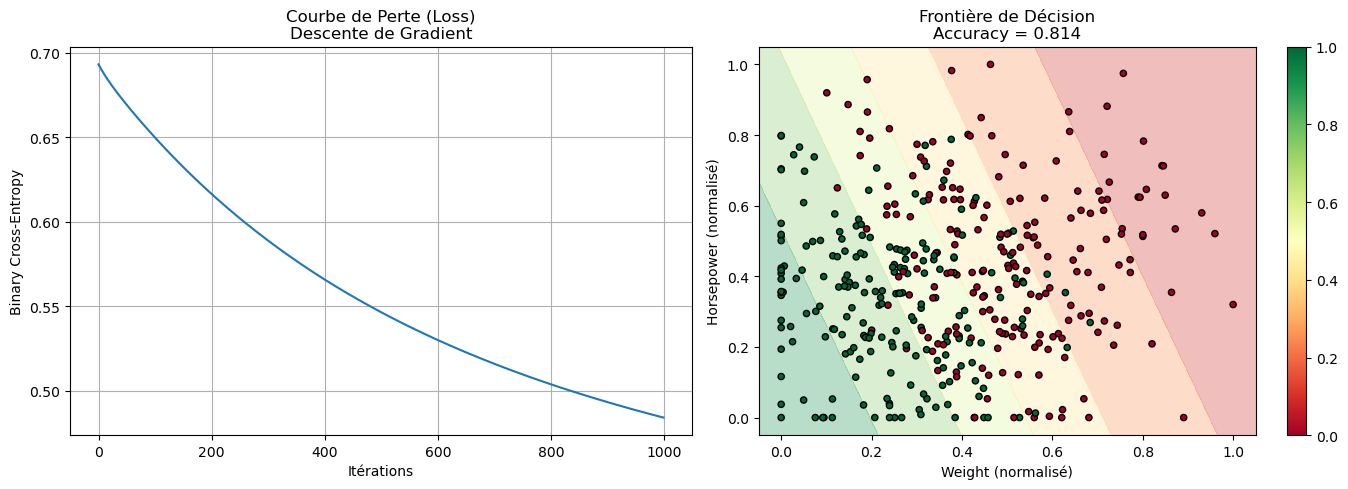

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))      

# courbe de la perte (convergence)
axes[0].plot(losses)
axes[0].set_title('Courbe de Perte (Loss)\nDescente de Gradient')
axes[0].set_xlabel('Itérations')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].grid(True)




# frontière de décision (weight vs horsepower)
x_min, x_max = X_n[:, 0].min() - 0.05, X_n[:, 0].max() + 0.05 
y_min, y_max = X_n[:, 1].min() - 0.05, X_n[:, 1].max() + 0.05 
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z    = sigmoid(grid @ w + b).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
scatter = axes[1].scatter(X_n[:, 0], X_n[:, 1], c=y, cmap='RdYlGn', edgecolors='k', s=20)
axes[1].set_title(f'Frontière de Décision\nAccuracy = {accuracy:.3f}')
axes[1].set_xlabel('Weight (normalisé)')
axes[1].set_ylabel('Horsepower (normalisé)')
plt.colorbar(scatter, ax=axes[1])





plt.tight_layout()                                    
plt.savefig('resultats_reglog_scratch.png', dpi=150)         
plt.show()                                            